# Analyze a dereverb batch

Loads one batch (by index) from a dataset split, runs the trained U-Net on every sample in the batch, and plots time-domain waveforms and spectrograms for **input** (reverberant), **output** (dereverbed), and **target** (clean).

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.signal import stft

from train import FRAME_LENGTH, FRAME_STEP, checkpoint_path, dataset, dereverb_model

I0000 00:00:1776254525.029388   64076 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Parameters

In [2]:
ver = 'prd'         # 'dev' or 'prd'
split = 'test'      # must stay 'test' to mirror test.py
batch_size = 16     # test.py default (--batch-size)
seed = 42           # test.py default (--seed)
sample_idx = 1
sr = 16000

## Load batch

In [3]:
# Mirror test.py exactly: unsorted glob, same batch size, same seed, same RNG call.
x_paths = tf.io.gfile.glob(f'./datasets/dereverb/{split}-{ver}/X/*.wav')
assert x_paths, f'No wavs found under ./datasets/dereverb/{split}-{ver}/X/'
ds = dataset(batch_size, x_paths)

np.random.seed(seed)
batch_idx = np.random.randint(0, len(ds))
print(f'batch index: {batch_idx}')

x_batch, y_batch = ds[batch_idx]  # (B, T)
print(f'batch {batch_idx}: {x_batch.shape[0]} samples x {x_batch.shape[1]} frames ({x_batch.shape[1]/sr:.2f}s each)')

batch index: 102
batch 102: 16 samples x 81920 frames (5.12s each)


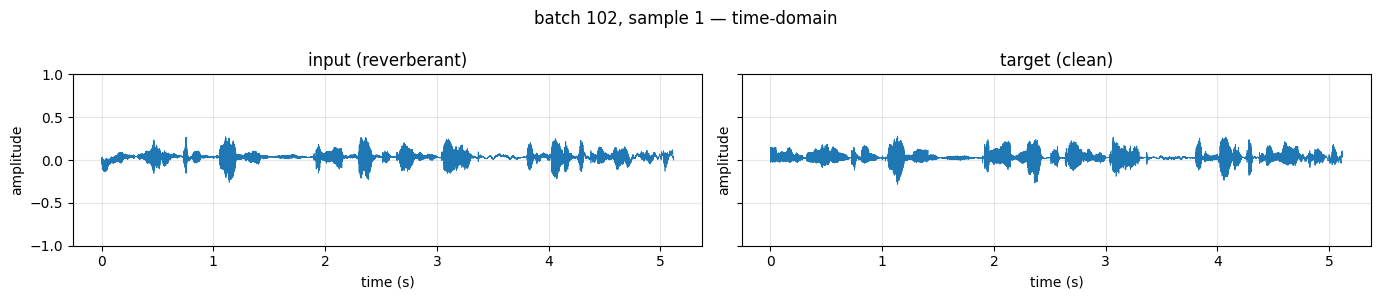

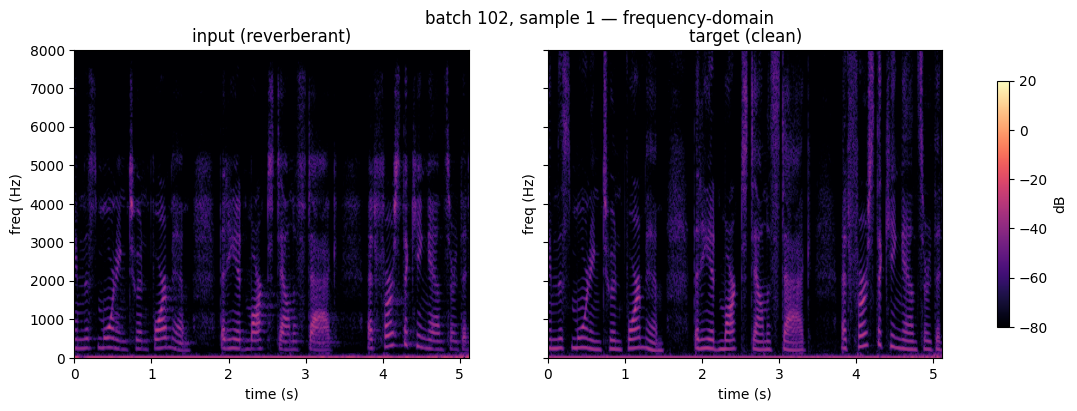

input (reverberant)


target (clean)


In [4]:
from IPython.display import Audio, display

x = x_batch[sample_idx]
y = y_batch[sample_idx]
T = x.shape[0]
t = np.arange(T) / sr

def spectrogram_db(signal):
    _, _, Z = stft(signal, fs=sr, nperseg=FRAME_LENGTH,
                   noverlap=FRAME_LENGTH - FRAME_STEP, boundary=None)
    return 20 * np.log10(np.abs(Z) + 1e-6)

vmin, vmax = -80, 20

fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharex=True, sharey=True)
fig.suptitle(f'batch {batch_idx}, sample {sample_idx} — time-domain')
for ax, sig, title in zip(axes, [x, y], ['input (reverberant)', 'target (clean)']):
    ax.plot(t, sig, lw=0.5)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xlabel('time (s)')
    ax.set_ylabel('amplitude')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
fig.suptitle(f'batch {batch_idx}, sample {sample_idx} — frequency-domain')
for ax, sig, title in zip(axes, [x, y], ['input (reverberant)', 'target (clean)']):
    S = spectrogram_db(sig)
    im = ax.imshow(S, vmin=vmin, vmax=vmax, origin='lower', aspect='auto',
                   cmap='magma', extent=[0, T / sr, 0, sr / 2])
    ax.set_xlabel('time (s)')
    ax.set_ylabel('freq (Hz)')
    ax.set_title(title)
fig.colorbar(im, ax=axes, label='dB', shrink=0.8)
plt.show()

print('input (reverberant)')
display(Audio(x, rate=sr))
print('target (clean)')
display(Audio(y, rate=sr))

In [5]:
np.std(x), np.std(y)

(np.float64(0.03756594358539494), np.float64(0.03757211797615053))